# Mid-term: Predictors for Log Home Price
Houpu Li 

## 1) Initial thoughts releated to real estate market in Santa Barbara
Based on my previous experience, I believe house prices are typically positively correlated with `house type(condo, mobile home, single family)`, `size`, `number of bedrooms and bathrooms`, `school district quality`, `Year Built`, and `location`. Most of these factors were validated in the video. Other factors I want to include are:

- **Mountain and ocean views**: I'll extract keywords "mountain view" and "ocean view" from the remark column
- **Distance to highway**: I expect negative correlation with price
- **School District**: I expect the if the house close to better school, they usually have better price
- **Wildfire zones**: May influence prediction results
- **Flooding zones**: May influence prediction results

I plan to test these predictors to determine their actual impact on log home prices in Santa Barbara.

Besides, considering house price usually has spatial spillover issues, in other words, maybe high-high concentration and low-low, I may want to use spatial weight to fix this effect?

Before any implemnentations, I will pick up the variables we already have.
- Dependent Variable(Y): `Sold price`(I will transfer that into `log_price`) | number(USD)
- Independent Variable(X):
    - Book Section | String
    - City | String
    - District | Integer
    - Year Built | interger
    - Apx # Acres | Interger
    - Total Units | String
    - Total Bedroom | Integer
    - Total Bathroom | Interger
    - Public Remark | I plan to extract key words of "Mountain view" or "Ocean View"
    - Recurring Fees | Some fees for HOA? I think any additional payments may be influence on house price
    - Latitute
    - Longtitute
    - Some other socio-demographic acs factors

## 2) Data Input, Basic Date exploration, Scatterplots

### Data Input

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

In [2]:
h_price = pd.read_csv('/Users/houpuli/Downloads/5-1-25 to 4-30-26 Sold Homes Data_with_ACS.csv')

In [3]:
h_price = h_price[['Book Section','Sold Price','District','City','Neighborhood','Apx Lot SqFt','Apx # Acres','Year Built', 'Total #Units', 'Total Bedrooms','Total Bathrooms','latitude','longitude','acs_population_density_per_sq_mi','acs_median_household_income','acs_education_rate_bachelors_plus','acs_homeownership_rate', 'Recurring Fees', 'Public Remarks']].copy()
num_cols = ['Sold Price','Apx Lot SqFt','Apx # Acres','acs_population_density_per_sq_mi','acs_median_household_income','acs_education_rate_bachelors_plus','acs_homeownership_rate']

for col in num_cols:
    h_price[col] = pd.to_numeric(h_price[col], errors='coerce')
    h_price[col] = h_price[col].replace(0, float('nan'))
h_price['size_sqft'] = h_price['Apx # Acres'] * 43560
h_price['size_sqft'] = h_price['size_sqft'].fillna(h_price['Apx Lot SqFt'])
h_price['size_sqft'] = h_price['size_sqft'].fillna(h_price['size_sqft'].median())
h_price['log_size_sqft'] = np.log(h_price['size_sqft'])
h_price = h_price.drop(columns=['size_sqft'])

h_price['Year Built'] =  h_price['Year Built'].replace(0, float('nan'))
h_price['Year Built'] = h_price['Year Built'].fillna(h_price['Year Built'].median())
h_price['build_age'] = 2026 - h_price['Year Built']
h_price['build_age_class'] = pd.cut(h_price['build_age'], bins=[0, 10, 20, 30, 40, 50, float('inf')], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '50+'])

h_price = h_price.rename(columns={'Total #Units': 'Total Units'})
h_price['Total Units'] = h_price['Total Units'].fillna(h_price['Total Units'].median())
h_price['Recurring Fees'].fillna('unknown', inplace=True)
h_price = h_price.rename(columns={'Book Section': 'housetype'})

acs_cols = ['acs_population_density_per_sq_mi','acs_median_household_income','acs_education_rate_bachelors_plus','acs_homeownership_rate']
for col in acs_cols:
    h_price[col] = h_price[col].fillna(h_price[col].median())
h_price['log_popden_sqmi'] = np.log(h_price['acs_population_density_per_sq_mi'])
h_price['log_med_inc'] = np.log(h_price['acs_median_household_income'])

h_price['mountain_view'] = h_price['Public Remarks'].str.contains('mountain view', case=False, na=False)
h_price['ocean_view'] = h_price['Public Remarks'].str.contains('ocean view', case=False, na=False)
h_price['log_h_price'] = np.log(h_price['Sold Price'])
h_price = h_price.drop(columns=['Sold Price'])

h_price_gdf = gpd.GeoDataFrame(h_price, geometry=gpd.points_from_xy(h_price.longitude, h_price.latitude), crs='EPSG:4326').drop(columns=['latitude', 'longitude','Apx Lot SqFt','Apx # Acres'])

Fire Hazard Severity Zone can be found from [CalFire](https://fire-hazard-severity-zones-rollout-calfire-forestry.hub.arcgis.com/pages/access-map), and you can download from the dropbox link [here](https://calfire.app.box.com/s/wahuw9ny7cgn89xpxh7092ur50r1pwvj)
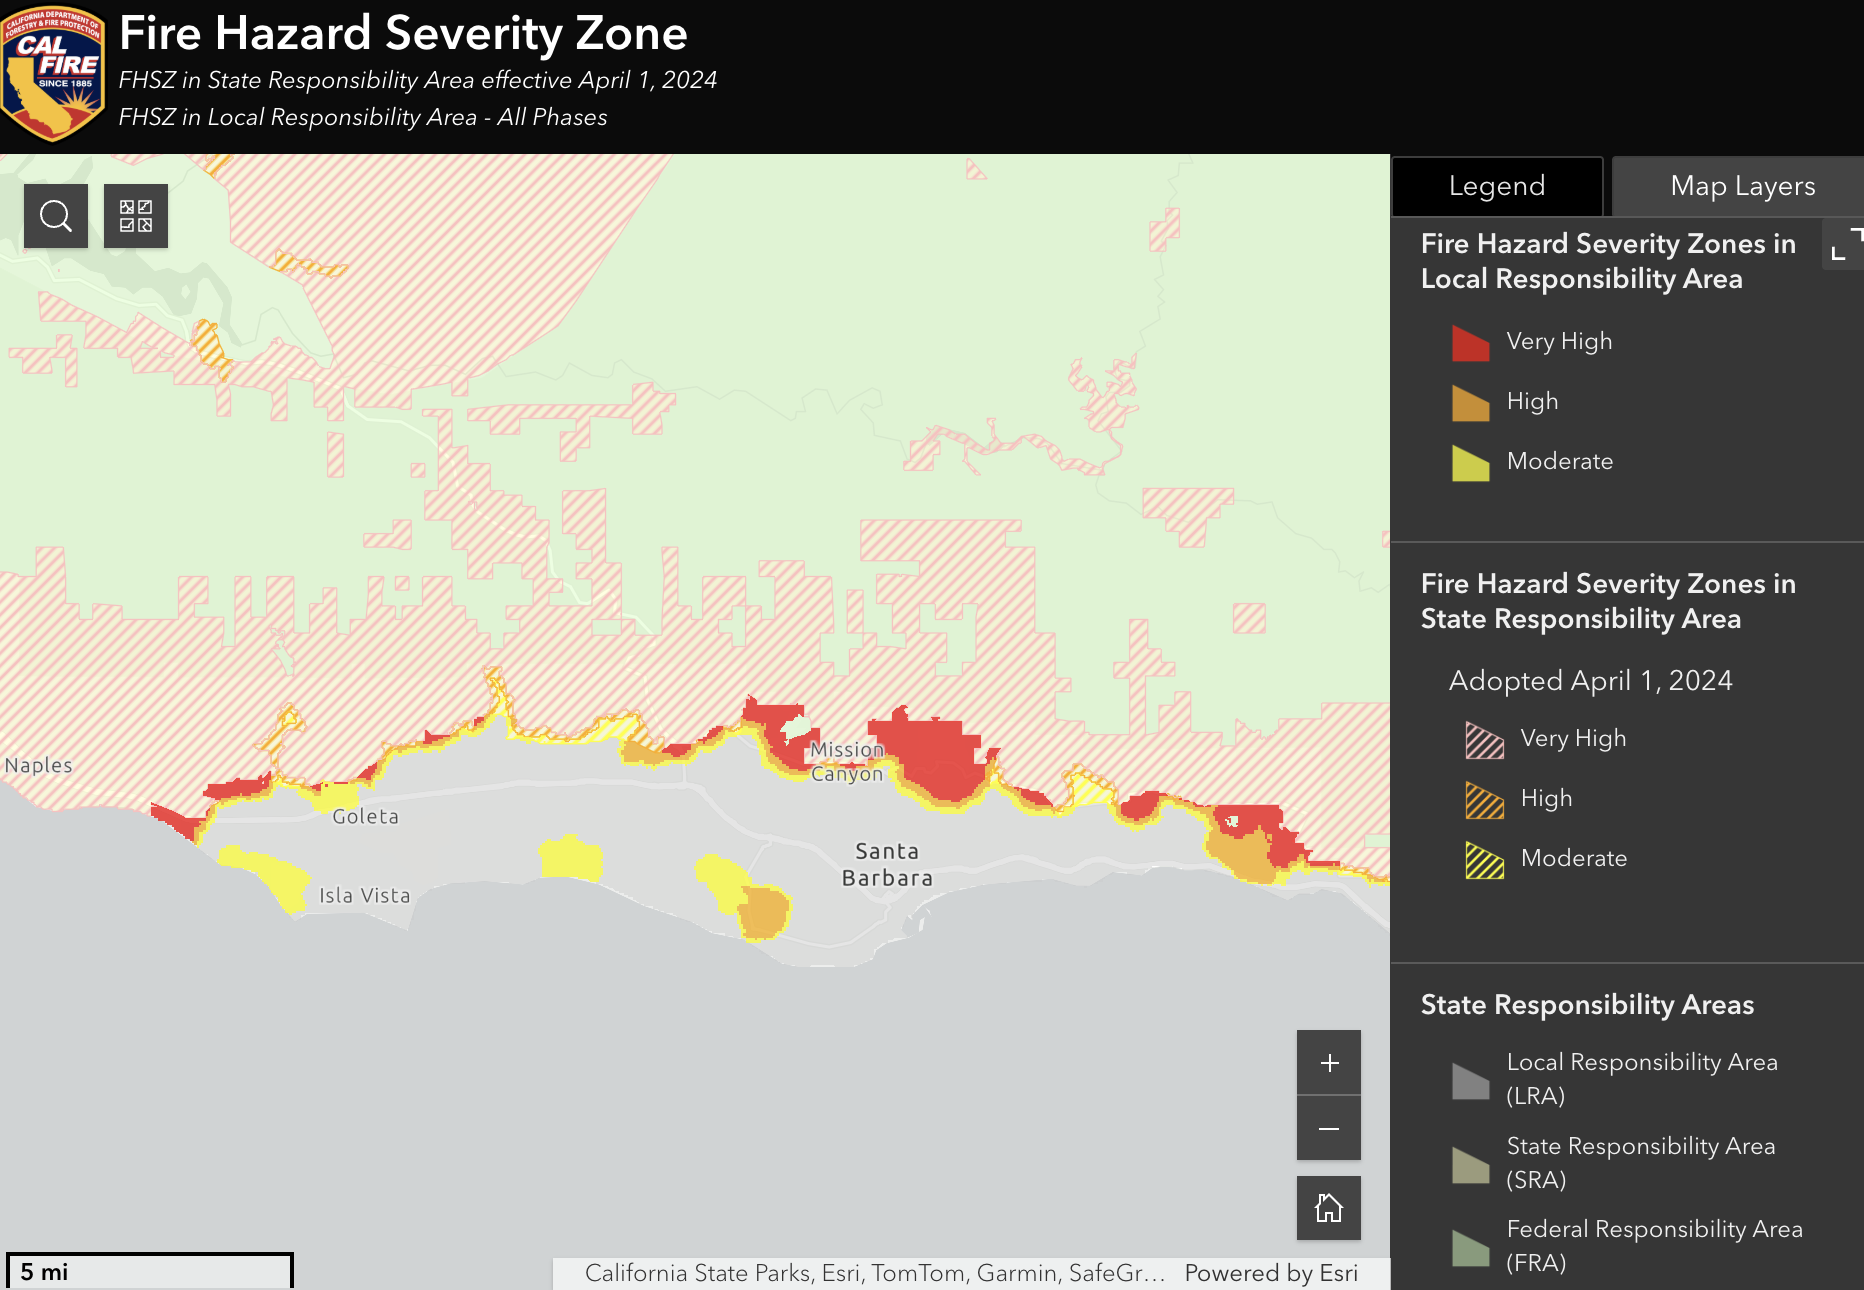

In [4]:
sb_firezone = gpd.read_file('/Users/houpuli/Downloads/shapefile/FHSZLRA25_Phase3_v1.shp')
sb_firezone = sb_firezone[sb_firezone['FHSZ_Descr'] != 'NonWildland']
sb_firezone = sb_firezone.to_crs(epsg=4326)

h_price_gdf = gpd.sjoin(h_price_gdf, sb_firezone[['geometry', 'FHSZ_Descr']], how='left', predicate='within').drop(columns=['index_right'])
h_price_gdf['FHSZ_Descr'].fillna('Normal', inplace=True)

In [5]:
h_price_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1419 entries, 0 to 1418
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   housetype                          1419 non-null   object  
 1   District                           1419 non-null   int64   
 2   City                               1419 non-null   object  
 3   Neighborhood                       600 non-null    object  
 4   Year Built                         1419 non-null   float64 
 5   Total Units                        1419 non-null   float64 
 6   Total Bedrooms                     1419 non-null   float64 
 7   Total Bathrooms                    1419 non-null   float64 
 8   acs_population_density_per_sq_mi   1419 non-null   float64 
 9   acs_median_household_income        1419 non-null   float64 
 10  acs_education_rate_bachelors_plus  1419 non-null   float64 
 11  acs_homeownership_rate             1419 

### Basic Exploration

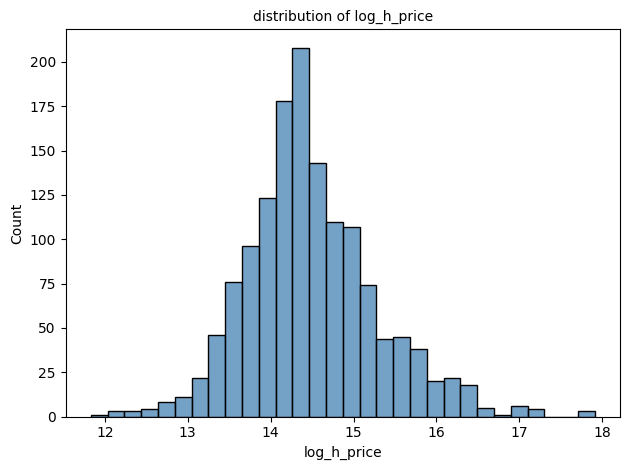

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(h_price_gdf['log_h_price'], bins=30, color='steelblue')

plt.title('distribution of log_h_price', fontsize=10)
plt.tight_layout()
plt.show()

### Scatter plot of log_h_price vs other predictors(Continues Variables)

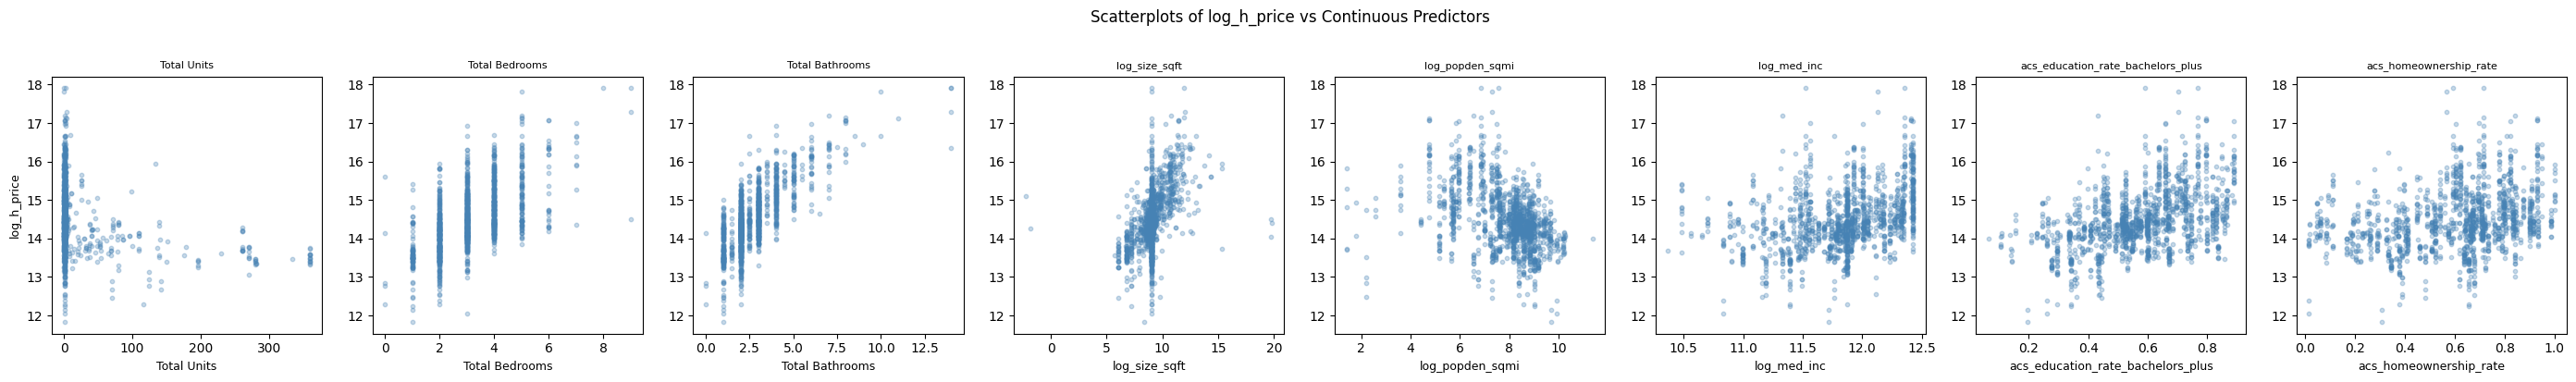

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

x_con_cols = ['Total Units', 'Total Bedrooms', 'Total Bathrooms', 'log_size_sqft', 'log_popden_sqmi', 'log_med_inc', 'acs_education_rate_bachelors_plus', 'acs_homeownership_rate']

fig, axes = plt.subplots(1, 8, figsize=(28, 4))

for i, col in enumerate(x_con_cols):
    axes[i].scatter(h_price_gdf[col], h_price_gdf['log_h_price'], 
                    alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('log_h_price' if i == 0 else '', fontsize=9)
    axes[i].set_title(col, fontsize=8)

plt.suptitle('Scatterplots of log_h_price vs Continuous Predictors', y=1.02)
plt.tight_layout()
plt.show()

### Boxplot of log_h_price vs other predictors(Catergroy Variables)

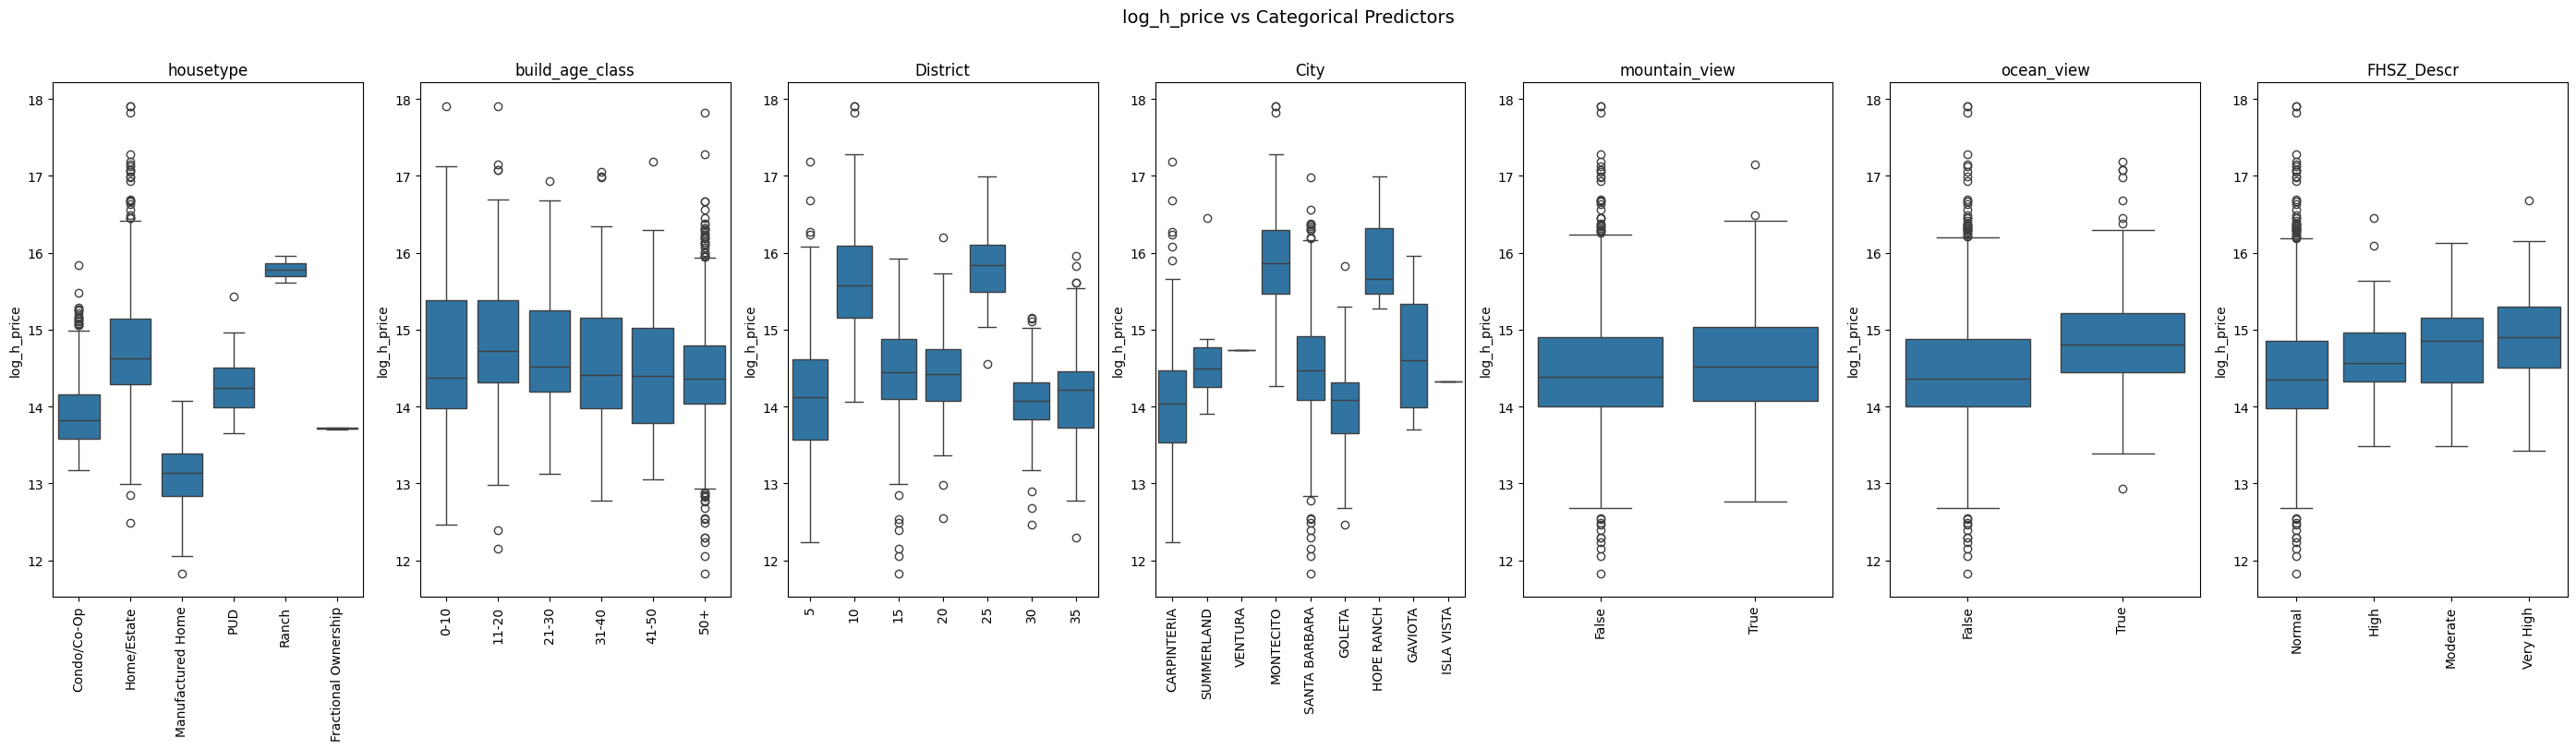

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

x_cat_cols = ['housetype', 'build_age_class', 'District', 'City',  'mountain_view', 'ocean_view', 'FHSZ_Descr']

fig, axes = plt.subplots(1, 7, figsize=(28, 8))
axes = axes.flatten()

for i, col in enumerate(x_cat_cols):
    data = h_price_gdf.dropna(subset=[col])
    sns.boxplot(x=col, y='log_h_price', data=data, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=90, labelsize=10)

plt.suptitle('log_h_price vs Categorical Predictors', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 3）Regression Modelling

### get dummies for categorical variables

In [9]:
h_price_gdf['mountain_view'] = h_price_gdf['mountain_view'].astype(int)
h_price_gdf['ocean_view'] = h_price_gdf['ocean_view'].astype(int)

age_order = {'0-10': 1, '11-20': 2, '21-30': 3, '31-40': 4, '41-50': 5, '50+': 6}
h_price_gdf['build_age_class'] = h_price_gdf['build_age_class'].map(age_order)

h_price_gdf = pd.get_dummies(h_price_gdf, columns=['housetype', 'City', 'District', 'FHSZ_Descr'], drop_first=True, dtype=int)

### Model 1: baseline OLS(exclude one-hot dummy)

In [10]:
import statsmodels.api as sm

cols_1 = ['log_size_sqft', 'Total Units', 'Total Bedrooms', 'Total Bathrooms', 'log_popden_sqmi', 'log_med_inc', 'acs_education_rate_bachelors_plus', 'acs_homeownership_rate', 'build_age_class', 'mountain_view', 'ocean_view']

X = h_price_gdf[cols_1].dropna()
y = h_price_gdf.loc[X.index, 'log_h_price']

X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_h_price   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     277.8
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        23:33:52   Log-Likelihood:                -868.81
No. Observations:                1419   AIC:                             1762.
Df Residuals:                    1407   BIC:                             1825.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

`mountain_view` being negative is worth noting(according to the real-estate market agent introduction, it should be positive correlation), i guess it may be because location (City/District) was not controlled? and mountain-view houses are concentrated in some cheaper areas.

### Model 2: Full OLS(control for city + district + household)

In [11]:
city_dummies = [col for col in h_price_gdf.columns if col.startswith('City_')]
district_dummies = [col for col in h_price_gdf.columns if col.startswith('District_')]
housetype_dummies = [col for col in h_price_gdf.columns if col.startswith('housetype_')]

cols_2 = cols_1 + city_dummies + district_dummies + housetype_dummies

X2 = h_price_gdf[cols_2].dropna()
y2 = h_price_gdf.loc[X2.index, 'log_h_price']
X2 = sm.add_constant(X2)

model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_h_price   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     241.4
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        23:33:52   Log-Likelihood:                -391.17
No. Observations:                1419   AIC:                             844.3
Df Residuals:                    1388   BIC:                             1007.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

### Model 3: Spatial Lag Model

In [12]:
import spreg
from libpysal.weights import KNN

X3 = h_price_gdf[cols_2].dropna()
y3 = h_price_gdf.loc[X3.index, 'log_h_price'].values

idx = X3.index.tolist()
w = KNN.from_array([(h_price_gdf.geometry.x[i], h_price_gdf.geometry.y[i]) for i in idx],k=8)
w.transform = 'r'

model3 = spreg.GM_Lag(
    y3,
    X3.values,
    w=w,
    name_y='log_h_price',
    name_x=cols_2,
)
print(model3.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : log_h_price                Number of Observations:        1419
Mean dependent var  :     14.4915                Number of Variables   :          32
S.D. dependent var  :      0.7952                Degrees of Freedom    :        1387
Pseudo R-squared    :      0.8520
Spatial Pseudo R-squared:  0.8395

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        11.58366         0.51865        22.33432         0.00000
       log_size_sqft         0.03942         0.00756         5.21377         0.00000
         Total Units        -0.00018      

/opt/anaconda3/envs/houpu_py/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  warnings.warn(message)


### Model 4: Bayesian Regression(See R.rmd html)

In [17]:
h_price_gdf['build_age_class'] = h_price_gdf['build_age_class'].astype(int)
h_price_gdf.to_file('/Users/houpuli/Downloads/h_price_gdf.geojson')